In [28]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

# Read words dataset
words = open('names.txt', 'r').read().splitlines()

# Build vocabulary mapping
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

# Build dataset function
block_size = 3
def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w:
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [29]:
words[:10]

['yuheng',
 'diondre',
 'xavien',
 'jori',
 'juanluis',
 'erandi',
 'phia',
 'samatha',
 'phoenix',
 'emmelynn']

In [30]:
len(words)

32033

In [31]:
min(len(w) for w in words)

2

In [32]:
max(len(w) for w in words)

15

In [33]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

. y
y u
u h
h e
e n
n g
g .
. d
d i
i o
o n
n d
d r
r e
e .
. x
x a
a v
v i
i e
e n
n .


In [34]:
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [35]:
sorted(b.items(), key = lambda kv: kv[1], reverse=True)

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [36]:
import torch

In [37]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [38]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [39]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

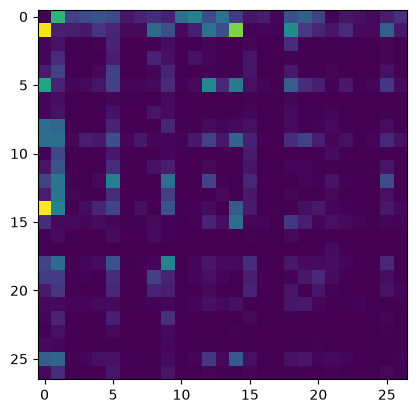

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(N)

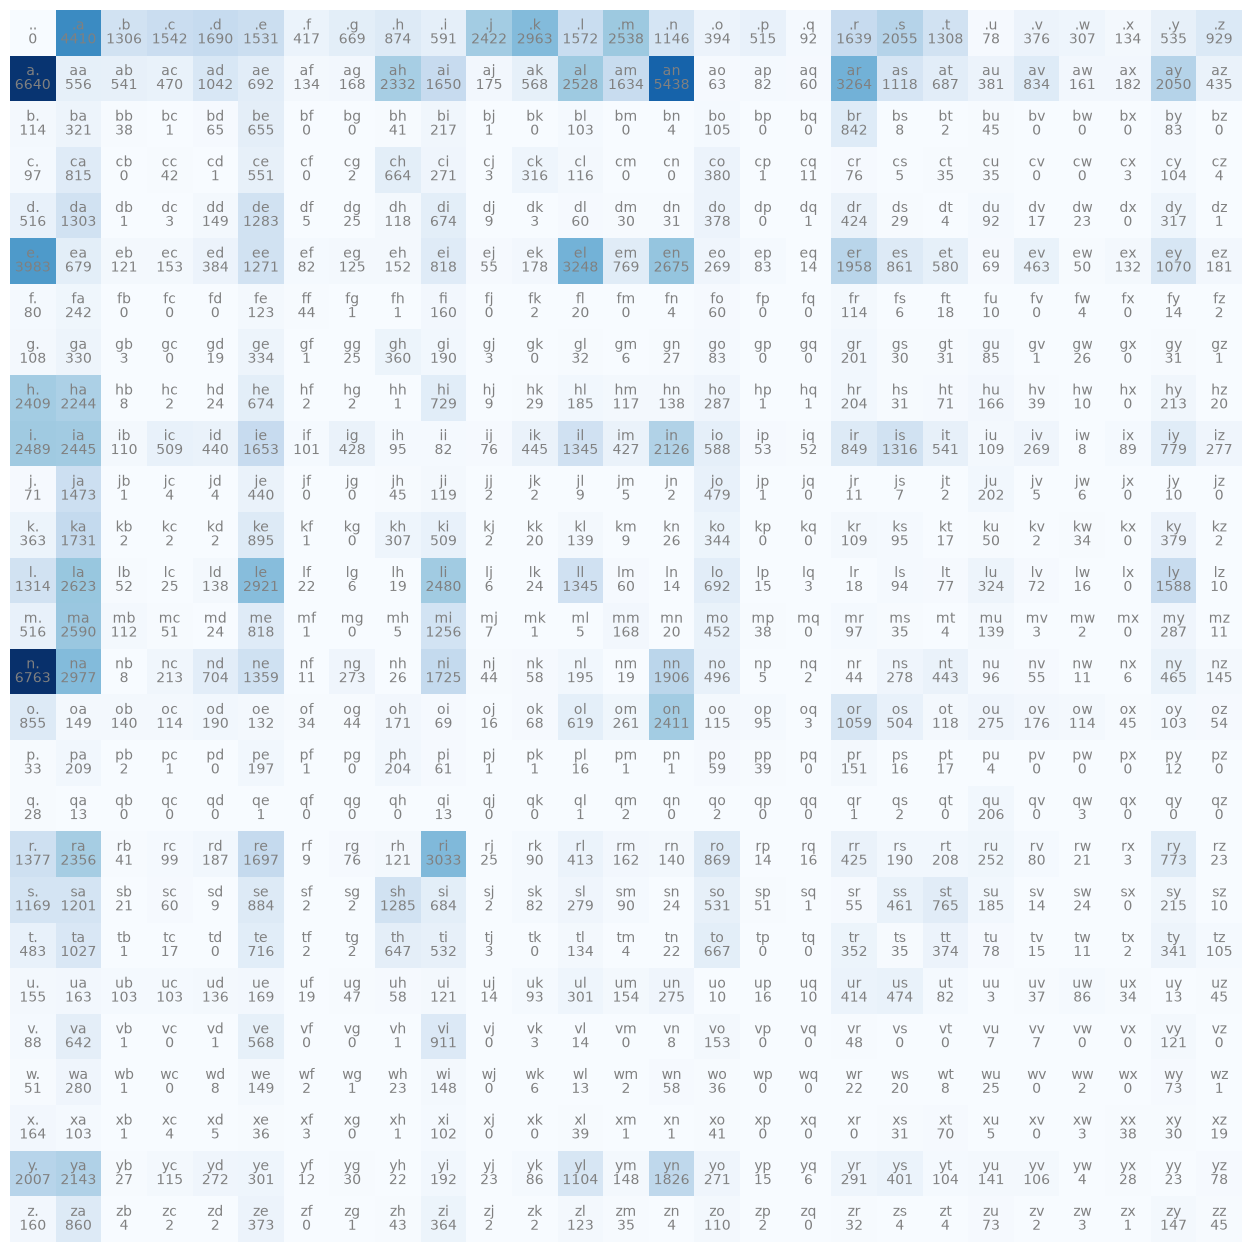

In [41]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [42]:
P = N.float()
P /= P.sum(1, keepdim=True)

In [43]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [44]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'average NLL (loss): {nll / n}')

log_likelihood=tensor(-559870.6250)
nll=tensor(559870.6250)
average NLL (loss): 2.4540014266967773


In [45]:
xs, ys = [], []

for w in words[:1]: # Testing on the first word first (e.g., 'emma')
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. y
y u
u h
h e
e n
n g
g .


In [46]:
import torch.nn.functional as F

In [47]:
xenc = F.one_hot(xs, num_classes=27).float()

In [48]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [49]:
logits = xenc @ W 
counts = logits.exp() 
probs = counts / counts.sum(1, keepdim=True) 

In [50]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [51]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdim=True) # probabilities for next character
loss = -probs[torch.arange(len(ys)), ys].log().mean() # FIX: len(ys) instead of 5
print(loss.item())

3.8672845363616943


In [52]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .y (indexes 0,25)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 25
probability assigned by the net to the correct character: 0.15368640422821045
log likelihood: -1.8728411197662354
negative log likelihood: 1.8728411197662354
--------
bigram example 2: yu (indexes 25,21)
input to the neural net: 25
output probabilities from the neural net: tensor([0.0301, 0.0080, 0.0090, 0.0151, 0.1318, 0.0101, 0.0206, 0.1885, 0.0614,
        0.0078, 0.0079, 0.0080, 0.0141, 0.0055, 0.0055, 0.0108, 0.0414, 0.0069,
        0.0166, 0.0103, 0.1739, 0.0434, 0.0061, 0.0906, 0.0125, 0.0531, 0.0111])
label (actual next character): 21
probability assigned by the net to the correct character: 0.04

In [53]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples:', num)

number of examples: 228146


In [54]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [55]:
for k in range(100):
   
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()
    print(f'step {k+1}/100, loss: {loss.item():.4f}')
    
    
    W.grad = None 
    loss.backward()
  
    W.data += -50 * W.grad

    

step 1/100, loss: 3.7686
step 2/100, loss: 3.3788
step 3/100, loss: 3.1611
step 4/100, loss: 3.0272
step 5/100, loss: 2.9345
step 6/100, loss: 2.8672
step 7/100, loss: 2.8167
step 8/100, loss: 2.7771
step 9/100, loss: 2.7453
step 10/100, loss: 2.7188
step 11/100, loss: 2.6965
step 12/100, loss: 2.6774
step 13/100, loss: 2.6608
step 14/100, loss: 2.6464
step 15/100, loss: 2.6337
step 16/100, loss: 2.6225
step 17/100, loss: 2.6125
step 18/100, loss: 2.6037
step 19/100, loss: 2.5958
step 20/100, loss: 2.5887
step 21/100, loss: 2.5823
step 22/100, loss: 2.5764
step 23/100, loss: 2.5711
step 24/100, loss: 2.5663
step 25/100, loss: 2.5618
step 26/100, loss: 2.5577
step 27/100, loss: 2.5539
step 28/100, loss: 2.5504
step 29/100, loss: 2.5472
step 30/100, loss: 2.5442
step 31/100, loss: 2.5414
step 32/100, loss: 2.5387
step 33/100, loss: 2.5363
step 34/100, loss: 2.5340
step 35/100, loss: 2.5318
step 36/100, loss: 2.5298
step 37/100, loss: 2.5279
step 38/100, loss: 2.5261
step 39/100, loss: 2.

In [56]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
       
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.


## Building makemore Part 2: MLP (Bengio et al. 2003)

In [57]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [58]:
words = open('names.txt', 'r').read().splitlines()

In [59]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [60]:
block_size = 3 # context length: how many characters do we take to predict the next one?

X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix]

In [61]:
X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [62]:
C = torch.randn((27, 2))

In [63]:
C[5]

tensor([0.9959, 0.0107])

In [64]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [65]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [66]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([228146, 100])

In [67]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [68]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [69]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
loss = -prob[torch.arange(228146), Y].log().mean()
loss

tensor(14.3406)

In [70]:
loss = F.cross_entropy(logits, Y)
loss

tensor(14.3406)

In [71]:
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters)

3481

In [72]:
for p in parameters:
  p.requires_grad = True

In [73]:
for _ in range(10):
  
  # forward pass
  emb = C[X]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y)
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  for p in parameters:
    p.data += -0.1 * p.grad

print(loss.item())

9.80954647064209


In [74]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [75]:
lri = []
lossi = []

for i in range(1000):
  
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))
  
  # forward pass
  emb = C[X[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Y[ix])
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  lri.append(lre[i])
  lossi.append(loss.item())

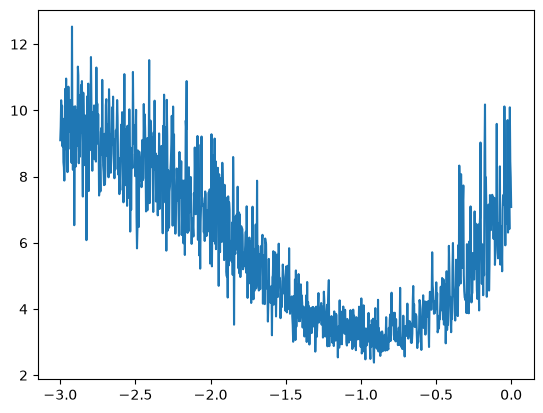

In [76]:
plt.plot(lri, lossi)

In [77]:
def build_dataset(words):
  block_size = 3
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [78]:
stepi = []
lossi = []

for i in range(30000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 20000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad
    
  # track stats
  stepi.append(i)
  lossi.append(loss.log10().item())

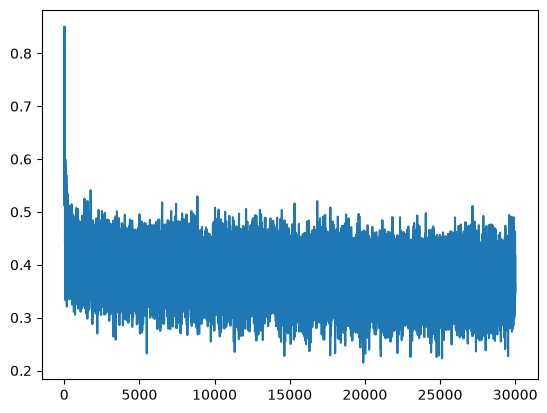

In [79]:
plt.plot(stepi, lossi)

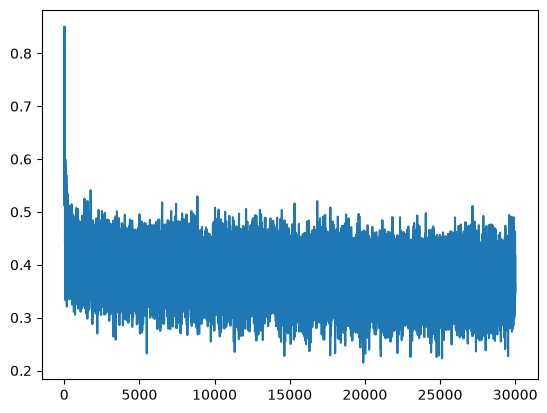

In [80]:
plt.plot(stepi, lossi)

In [81]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3261, grad_fn=<NllLossBackward0>)

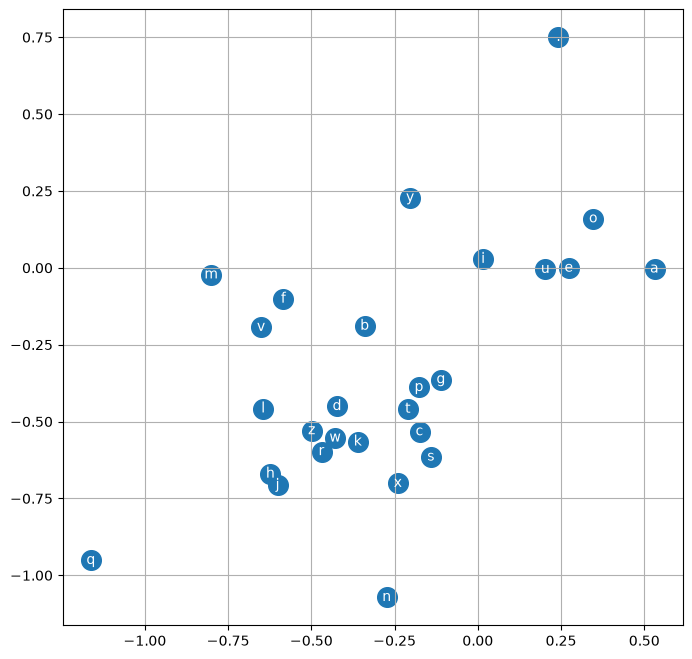

In [82]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [83]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])]
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

careah.
ambyllei.
kimlex.
thty.
hacansa.
jazhuen.
deliah.
jareei.
nelania.
chaiir.
kaleig.
dham.
poin.
quinn.
shoilea.
jadbi.
wazelon.
jaryni.
jace.
pirsa.


## Part 3: Activations & Gradients, BatchNorm

In [84]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

block_size = 3

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [85]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

emb = C[Xtr[:32]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[:32])
loss

tensor(18.4769, grad_fn=<NllLossBackward0>)

In [86]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g) * 0.01
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

emb = C[Xtr[:32]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[:32])
loss

tensor(3.2832, grad_fn=<NllLossBackward0>)

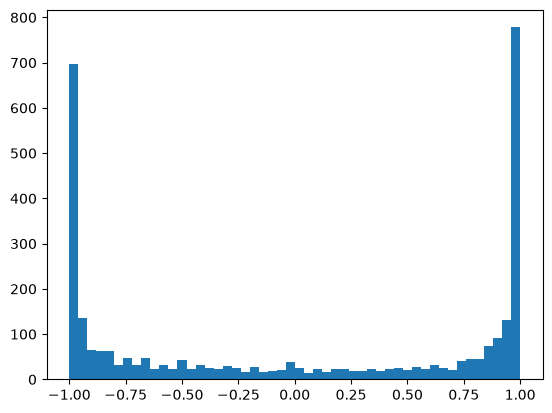

In [87]:
plt.hist(h.view(-1).data, 50);

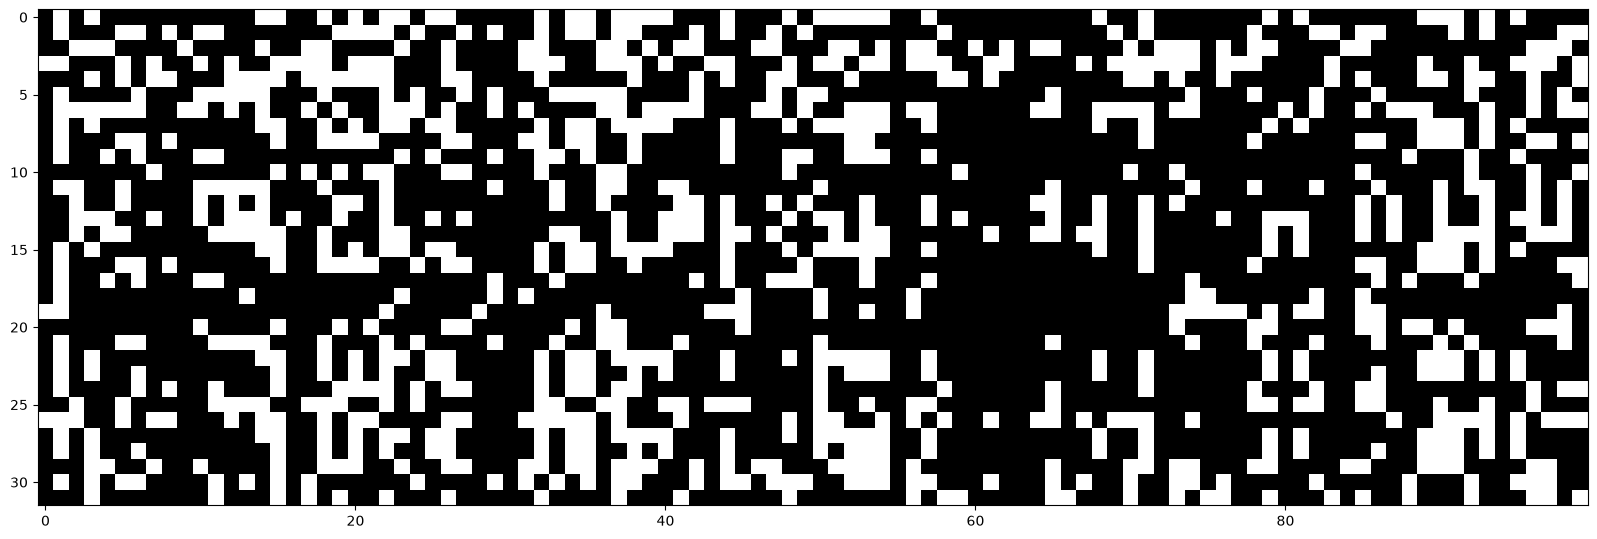

In [88]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [89]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g) * (5/3) / ((3*2)**0.5) # 3*2 = 6 inputs
b1 = torch.randn(100, generator=g) * 0.01
W2 = torch.randn((100, 27), generator=g) * 0.01
b2 = torch.zeros(27)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

emb = C[Xtr[:32]]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr[:32])
loss

tensor(3.2835, grad_fn=<NllLossBackward0>)

In [90]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g) * (5/3) / ((3*2)**0.5)
b1 = torch.randn(100, generator=g) * 0.01
W2 = torch.randn((100, 27), generator=g) * 0.01
b2 = torch.zeros(27)

# BatchNorm parameters
bngain = torch.ones((1, 100))
bnbias = torch.zeros((1, 100))
bnmean_running = torch.zeros((1, 100))
bnstd_running = torch.ones((1, 100))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

for p in parameters:
  p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  
  # forward pass
  emb = C[Xtr[ix]] # embed the characters into vectors
  hpreact = emb.view(-1, 6) @ W1 + b1 # hidden layer pre-activation
  
  # Batch Normalization
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Ytr[ix]) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3019
  10000/ 200000: 2.0571
  20000/ 200000: 2.4707
  30000/ 200000: 2.1782
  40000/ 200000: 2.3907
  50000/ 200000: 2.4990
  60000/ 200000: 2.6540
  70000/ 200000: 2.0267
  80000/ 200000: 2.2061
  90000/ 200000: 2.4000
 100000/ 200000: 2.4483
 110000/ 200000: 2.4156
 120000/ 200000: 2.4249
 130000/ 200000: 2.2436
 140000/ 200000: 2.3510
 150000/ 200000: 2.1793
 160000/ 200000: 2.6608
 170000/ 200000: 2.1352
 180000/ 200000: 2.1605
 190000/ 200000: 1.9896


In [91]:
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  hpreact = emb.view(emb.shape[0], -1) @ W1 + b1 # (N, 6) shape explicitly maintain karega
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.2424051761627197
val 2.2478106021881104


In [92]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
    
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with grad)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with running momentum update)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
    
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [93]:
n_embd = 10 # dimensionality of character embedding vectors
n_hidden = 100 # number of neurons in hidden layers
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, n_embd), generator=g)

# Stacking layers into a sequential list
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(          n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(          n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(          n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(          n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(          n_hidden, 27, bias=False), BatchNorm1d(27),
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, BatchNorm1d):
      layer.gamma *= 1.0

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(f"Total parameters: {sum(p.nelement() for p in parameters)}")

for p in parameters:
  p.requires_grad = True

Total parameters: 47024


In [94]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # ONLY for debugging/visualizations later
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())



      0/ 200000: 3.2870
  10000/ 200000: 2.3273
  20000/ 200000: 2.1019
  30000/ 200000: 1.9020
  40000/ 200000: 2.1643
  50000/ 200000: 2.1520
  60000/ 200000: 1.7767
  70000/ 200000: 2.1514
  80000/ 200000: 2.3802
  90000/ 200000: 1.9338
 100000/ 200000: 2.3943
 110000/ 200000: 2.1620
 120000/ 200000: 2.1407
 130000/ 200000: 2.0210
 140000/ 200000: 1.7178
 150000/ 200000: 1.9392
 160000/ 200000: 1.9819
 170000/ 200000: 2.0205
 180000/ 200000: 2.2461
 190000/ 200000: 1.9765


In [95]:
# Evaluation Split Loss Function
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    layer.training = False # set BatchNorm to eval mode
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0077314376831055
val 2.0803396701812744


layer 2 (      Tanh): mean +0.01, std 0.70, saturated: 16.19%
layer 5 (      Tanh): mean -0.02, std 0.73, saturated: 18.35%
layer 8 (      Tanh): mean +0.01, std 0.76, saturated: 17.60%
layer 11 (      Tanh): mean +0.01, std 0.78, saturated: 20.27%
layer 14 (      Tanh): mean +0.02, std 0.79, saturated: 22.53%


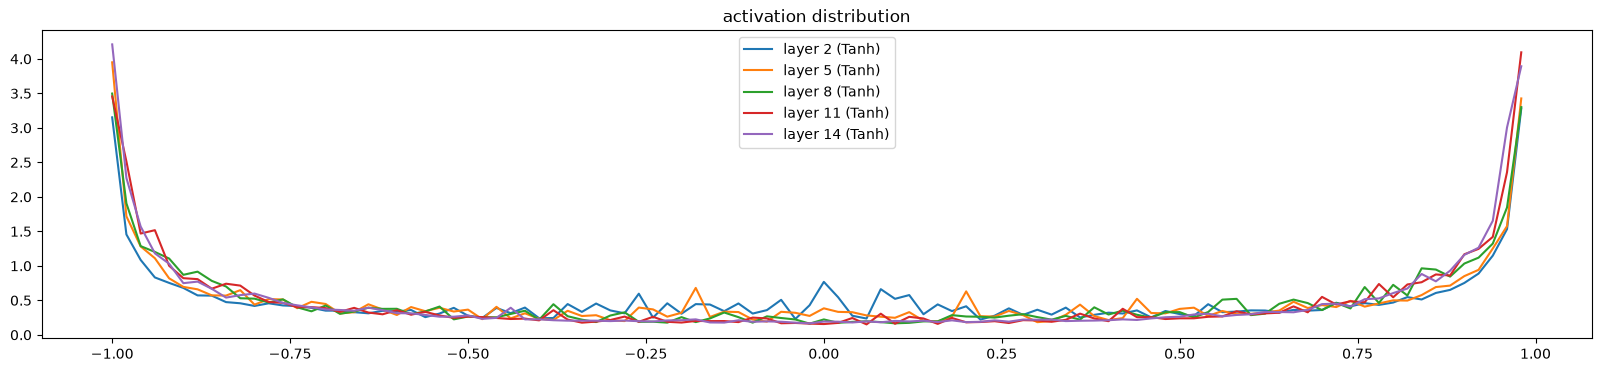

In [96]:
# Forward pass activations distribution plot
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution');

C:\Users\NANDANI PATIL\AppData\Local\Temp\ipykernel_36596\1334855708.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  print('weight %10s | mean %+f | std %e | log10(grad/data std) %.2f' %


weight   (27, 10) | mean -0.019305 | std 1.085759e+00 | log10(grad/data std) -3.75
weight  (30, 100) | mean +0.006561 | std 3.532174e-01 | log10(grad/data std) -3.52
weight (100, 100) | mean -0.000600 | std 2.134049e-01 | log10(grad/data std) -3.54
weight (100, 100) | mean -0.000840 | std 2.101899e-01 | log10(grad/data std) -3.57
weight (100, 100) | mean +0.004847 | std 2.016497e-01 | log10(grad/data std) -3.57
weight (100, 100) | mean +0.000317 | std 1.898105e-01 | log10(grad/data std) -3.55
weight  (100, 27) | mean -0.001610 | std 3.077087e-01 | log10(grad/data std) -3.53


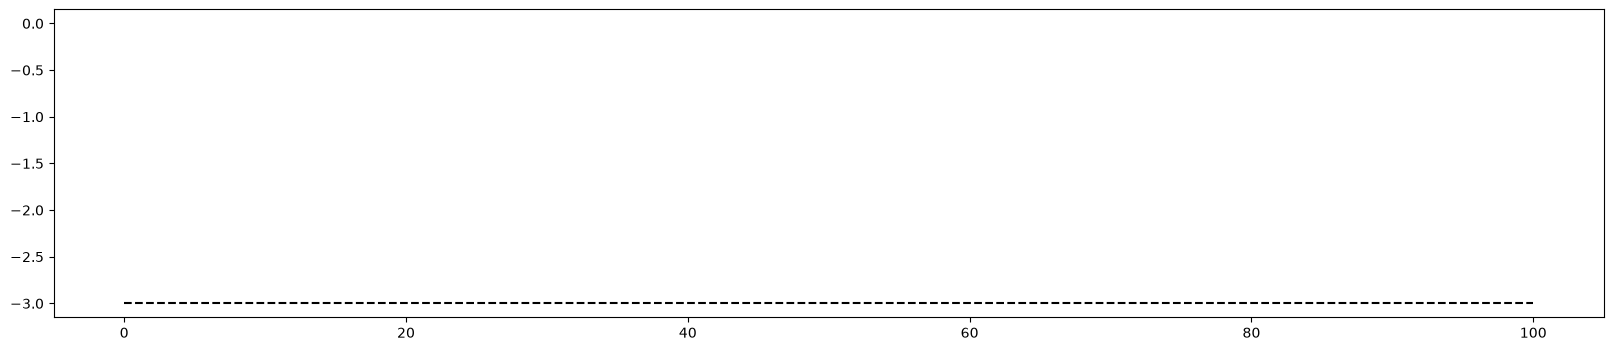

<Figure size 2000x400 with 0 Axes>

In [98]:
import matplotlib.pyplot as plt

# Parameters weight updates vs data ratio plot
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
  if p.ndim == 2: # only track weight matrices (excluding 1D vectors/biases)
    plt.plot([lr * p.grad.std() / p.data.std()]) # rough update ratio estimate
    legends.append(f'param {i} ({p.shape})')

# Draw target reference line at ~1e-3 (0.001) ratio
plt.plot([0, 100], [-3, -3], 'k--', label='target ratio ~1e-3')

plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
  if p.ndim == 2:
    t = p.grad
    print('weight %10s | mean %+f | std %e | log10(grad/data std) %.2f' % 
          (tuple(p.shape), p.mean(), p.std(), (lr * p.grad.std() / p.data.std()).log10().item()))

In [99]:
# Quick single batch forward + backward pass to capture gradients
ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

# Forward pass
emb = C[Xb]
x = emb.view(emb.shape[0], -1)
for layer in layers:
  x = layer(x)
loss = F.cross_entropy(x, Yb)

# Retain gradients for visualization
for layer in layers:
  layer.out.retain_grad()

# Backward pass
for p in parameters:
  p.grad = None
loss.backward()

weight   (27, 10) | mean -0.019305 | std 1.085759e+00 | log10(grad/data std) -3.92
weight  (30, 100) | mean +0.006561 | std 3.532174e-01 | log10(grad/data std) -3.59
weight (100, 100) | mean -0.000600 | std 2.134049e-01 | log10(grad/data std) -3.57
weight (100, 100) | mean -0.000840 | std 2.101899e-01 | log10(grad/data std) -3.51
weight (100, 100) | mean +0.004847 | std 2.016497e-01 | log10(grad/data std) -3.54
weight (100, 100) | mean +0.000317 | std 1.898105e-01 | log10(grad/data std) -3.54
weight  (100, 27) | mean -0.001610 | std 3.077087e-01 | log10(grad/data std) -3.48


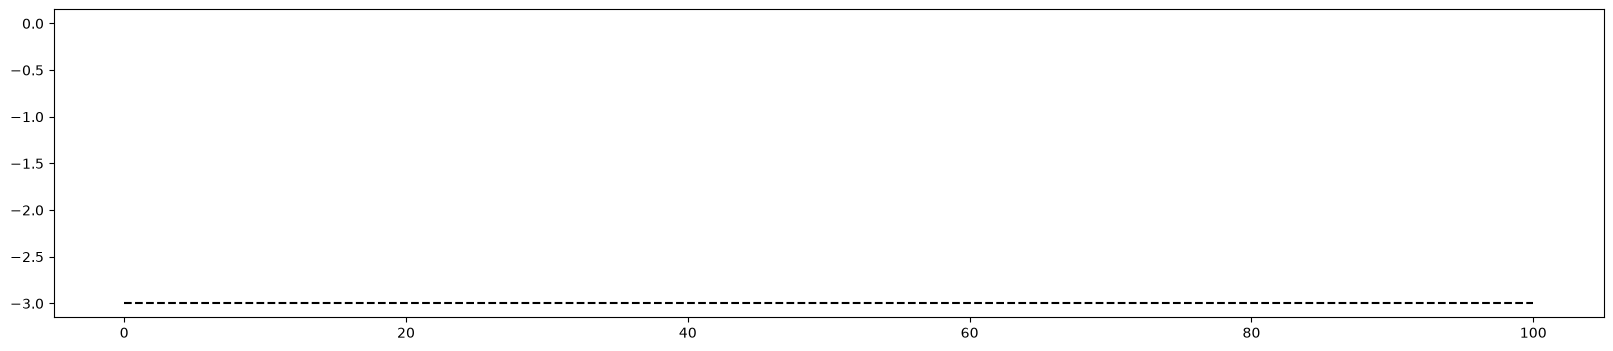

<Figure size 2000x400 with 0 Axes>

In [100]:
# Parameters weight updates vs data ratio plot
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
  if p.ndim == 2: # only track weight matrices (excluding 1D vectors/biases)
    plt.plot([lr * p.grad.std() / p.data.std()]) # rough update ratio estimate
    legends.append(f'param {i} ({p.shape})')

# Draw target reference line at ~1e-3 (0.001) ratio
plt.plot([0, 100], [-3, -3], 'k--', label='target ratio ~1e-3')

plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
  if p.ndim == 2:
    # Tracking logged ratio across training iterations
    # Note: In a full run, we log update_to_data ratios inside the training loop:
    # log_ratio = (lr * p.grad.std() / p.data.std()).log10().item()
    t = p.grad
    print('weight %10s | mean %+f | std %e | log10(grad/data std) %.2f' % 
          (tuple(p.shape), p.mean(), p.std(), (lr * p.grad.std() / p.data.std()).log10().item()))